# N-gram TF-IDF EDA of Hearing Utterances

Exploratory analysis of **n-gram TF-IDF** representations of the `text` column in `utterances_sample_labeled.csv`.

The n-gram range is configurable via `MIN_NGRAM` and `MAX_NGRAM` parameters.

**Outline**
1. Load & basic profiling
2. Build TF-IDF matrices (per-n and combined)
3. Remove n-grams that are contained within longer n-grams (keep only *maximal* n-grams)
4. Top-10 n-grams most correlated with each `speaker.position` and `section` class (one-vs-rest)
5. K-Means clustering of the TF-IDF embedding (model selection, cluster profiles, agreement with labels)
6. t-SNE 2-D embedding coloured by `speaker.position`, `section`, and cluster

In [ ]:
import warnings, re
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", 80)
RANDOM_STATE = 42

DATA_PATH = "utterances_sample_labeled.csv"   # adjust if needed

# ===== N-GRAM CONFIGURATION =====
MIN_NGRAM = 2  # Minimum n-gram size
MAX_NGRAM = 9  # Maximum n-gram size
# ================================

## 1. Load and profile the data

In [ ]:
df = pd.read_csv(DATA_PATH)
print("Raw shape:", df.shape)
df = df.dropna(subset=["text"]).copy()
df["text"] = df["text"].astype(str)
df["n_words"] = df["text"].str.split().str.len()
print("After dropping empty text:", df.shape)
df.head(3)

Raw shape: (2619, 8)
After dropping empty text: (2618, 9)


,state,bid,hid,uid,pid,speaker.position,section,text,n_words
0,CA,CA_201520160AB2050,255341,0,55,PRESIDING_CHAIR,INTRO,ORG woman BILL_AUTHOR you have three matters if it's all right with you BILL...,80
1,CA,CA_201520160AB2050,255341,1,101330,BILL_AUTHOR,PRESENTATION,good morning mr chair and members thank you for the opportunity to present B...,369
2,CA,CA_201520160AB2050,255341,2,55,PRESIDING_CHAIR,PRESENTATION,that is correct what they've been doing we've got a variety of bills to try ...,24


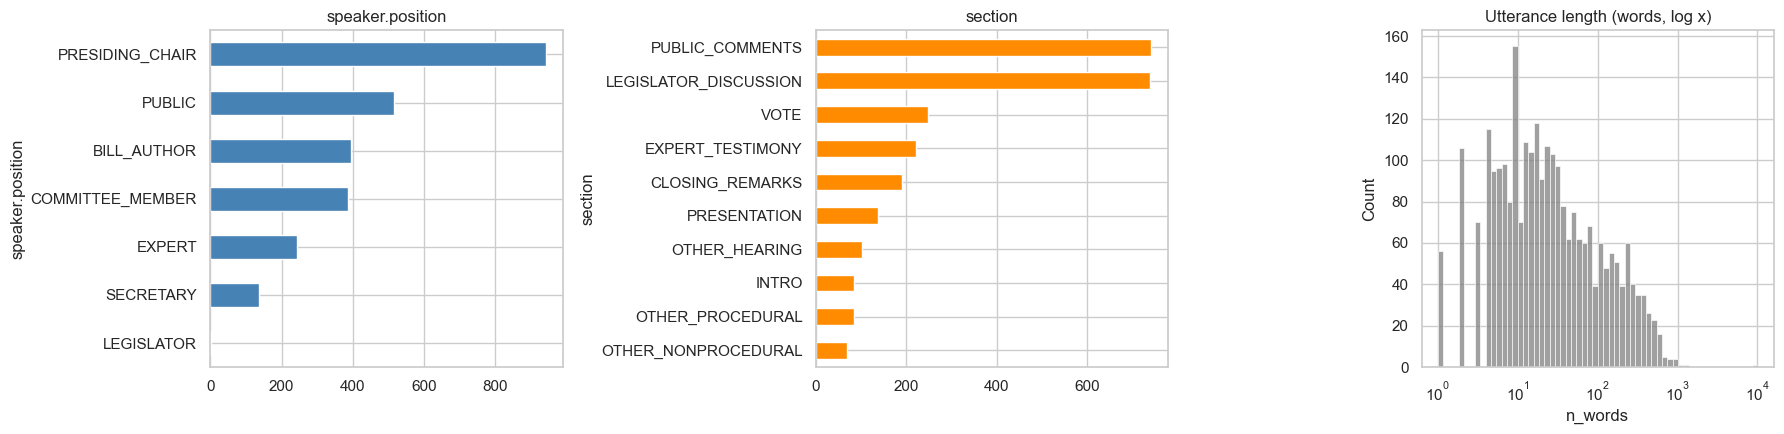

,count,mean,std,min,25%,50%,75%,max
n_words,2618.0,72.124523,231.042878,1.0,8.0,20.0,66.0,10154.0


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
df["speaker.position"].value_counts().plot.barh(ax=axes[0], color="steelblue")
axes[0].set_title("speaker.position"); axes[0].invert_yaxis()
df["section"].value_counts().plot.barh(ax=axes[1], color="darkorange")
axes[1].set_title("section"); axes[1].invert_yaxis()
sns.histplot(df["n_words"], bins=60, log_scale=True, ax=axes[2], color="gray")
axes[2].set_title("Utterance length (words, log x)")
plt.tight_layout(); plt.show()

df["n_words"].describe().to_frame("n_words").T

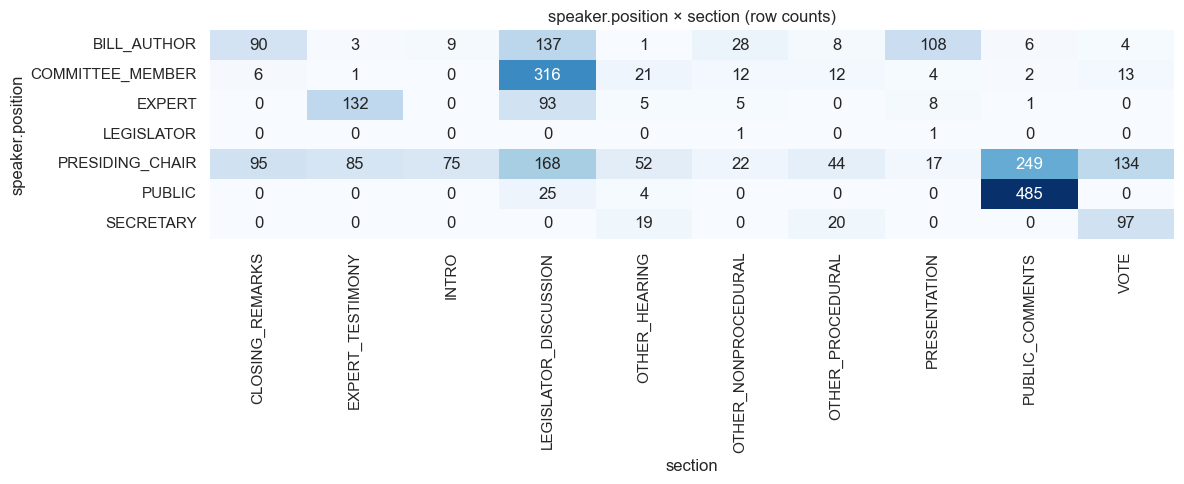

In [ ]:
# Cross-tab of the two label columns — useful context for interpreting clusters later
ct = pd.crosstab(df["speaker.position"], df["section"])
plt.figure(figsize=(12, 5))
sns.heatmap(ct, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("speaker.position × section (row counts)")
plt.tight_layout(); plt.show()

## 2. TF-IDF n-gram features

Notes on preprocessing:
- The text is already lower-cased and has entity placeholders (`ORG`, `BILL`, `BILL_AUTHOR`, `AB2050`, …). We keep these as tokens — they are informative for role/section.
- Token pattern keeps alphanumerics and underscores (so `BILL_AUTHOR` stays one token) and allows 1-char tokens like `i`.
- `min_df=3` drops n-grams that appear in fewer than 3 utterances; `sublinear_tf=True` dampens the very long presentation utterances.
- Utterances are extremely skewed in length (median ≈ 20 words, max > 10k), so L2 row-normalisation (the default) matters.

In [ ]:
TOKEN_PATTERN = r"(?u)\b\w+\b"

def make_vectorizer(ngram_range, min_df=3):
    return TfidfVectorizer(
        ngram_range=ngram_range,
        token_pattern=TOKEN_PATTERN,
        lowercase=False,          # already lower-cased except placeholders; keep case
        min_df=min_df,
        max_df=0.95,
        sublinear_tf=True,
        norm="l2",
        dtype=np.float32,
    )

texts = df["text"].tolist()
ngram_range = range(MIN_NGRAM, MAX_NGRAM + 1)

# Per-n matrices for comparison + combined matrix used for clustering & correlations
tfidf = {}
for n in ngram_range:
    vec = make_vectorizer((n, n))
    X = vec.fit_transform(texts)
    tfidf[n] = (vec, X)
    print(f"{n}-grams: {X.shape[1]:>7,} features | nnz/doc = {X.nnz/X.shape[0]:.1f} | "
          f"docs with no feature = {(X.getnnz(axis=1)==0).sum()}")

vec_all = make_vectorizer((MIN_NGRAM, MAX_NGRAM))
X_all = vec_all.fit_transform(texts)
feat_all = np.array(vec_all.get_feature_names_out())
print(f"\ncombined {MIN_NGRAM}–{MAX_NGRAM}-grams: {X_all.shape[1]:,} features")

2-grams:   9,890 features | nnz/doc = 36.8 | docs with no feature = 83
3-grams:   5,858 features | nnz/doc = 14.6 | docs with no feature = 323
4-grams:   2,216 features | nnz/doc = 4.9 | docs with no feature = 698
5-grams:     950 features | nnz/doc = 1.9 | docs with no feature = 1298
6-grams:     455 features | nnz/doc = 0.9 | docs with no feature = 1814
7-grams:     239 features | nnz/doc = 0.4 | docs with no feature = 2167
8-grams:     128 features | nnz/doc = 0.2 | docs with no feature = 2409
9-grams:      71 features | nnz/doc = 0.1 | docs with no feature = 2509

combined 2–9-grams: 19,807 features


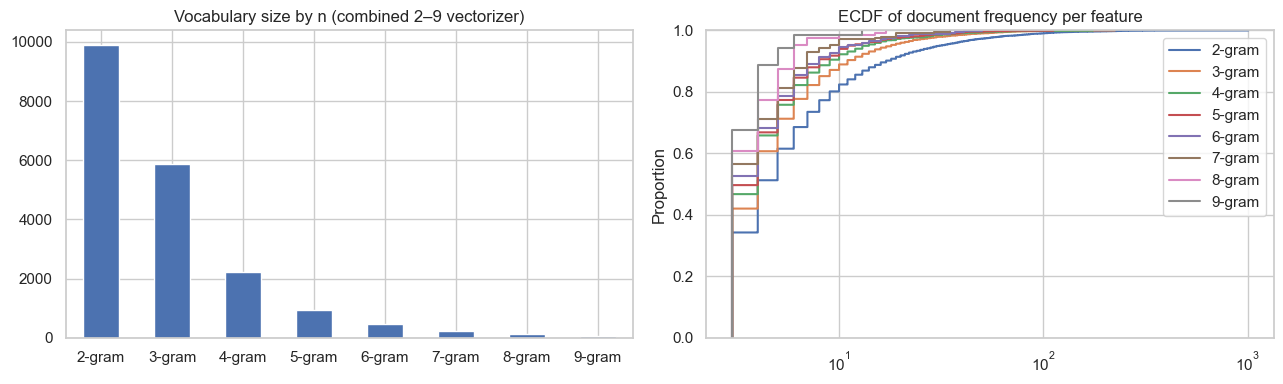

,n_features
2-gram,9890
3-gram,5858
4-gram,2216
5-gram,950
6-gram,455
7-gram,239
8-gram,128
9-gram,71


In [ ]:
# Vocabulary composition of the combined matrix and sparsity per n
ngram_len = np.array([len(f.split()) for f in feat_all])
comp = pd.Series(ngram_len).value_counts().sort_index().rename("n_features")
comp.index = [f"{i}-gram" for i in comp.index]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
comp.plot.bar(ax=axes[0], rot=0)
axes[0].set_title(f"Vocabulary size by n (combined {MIN_NGRAM}–{MAX_NGRAM} vectorizer)")

# document frequency distributions
for n, (vec, X) in tfidf.items():
    dfreq = np.asarray((X > 0).sum(axis=0)).ravel()
    sns.ecdfplot(dfreq, ax=axes[1], label=f"{n}-gram", log_scale=True)
axes[1].set_title("ECDF of document frequency per feature"); axes[1].legend()
plt.tight_layout(); plt.show()
comp.to_frame()

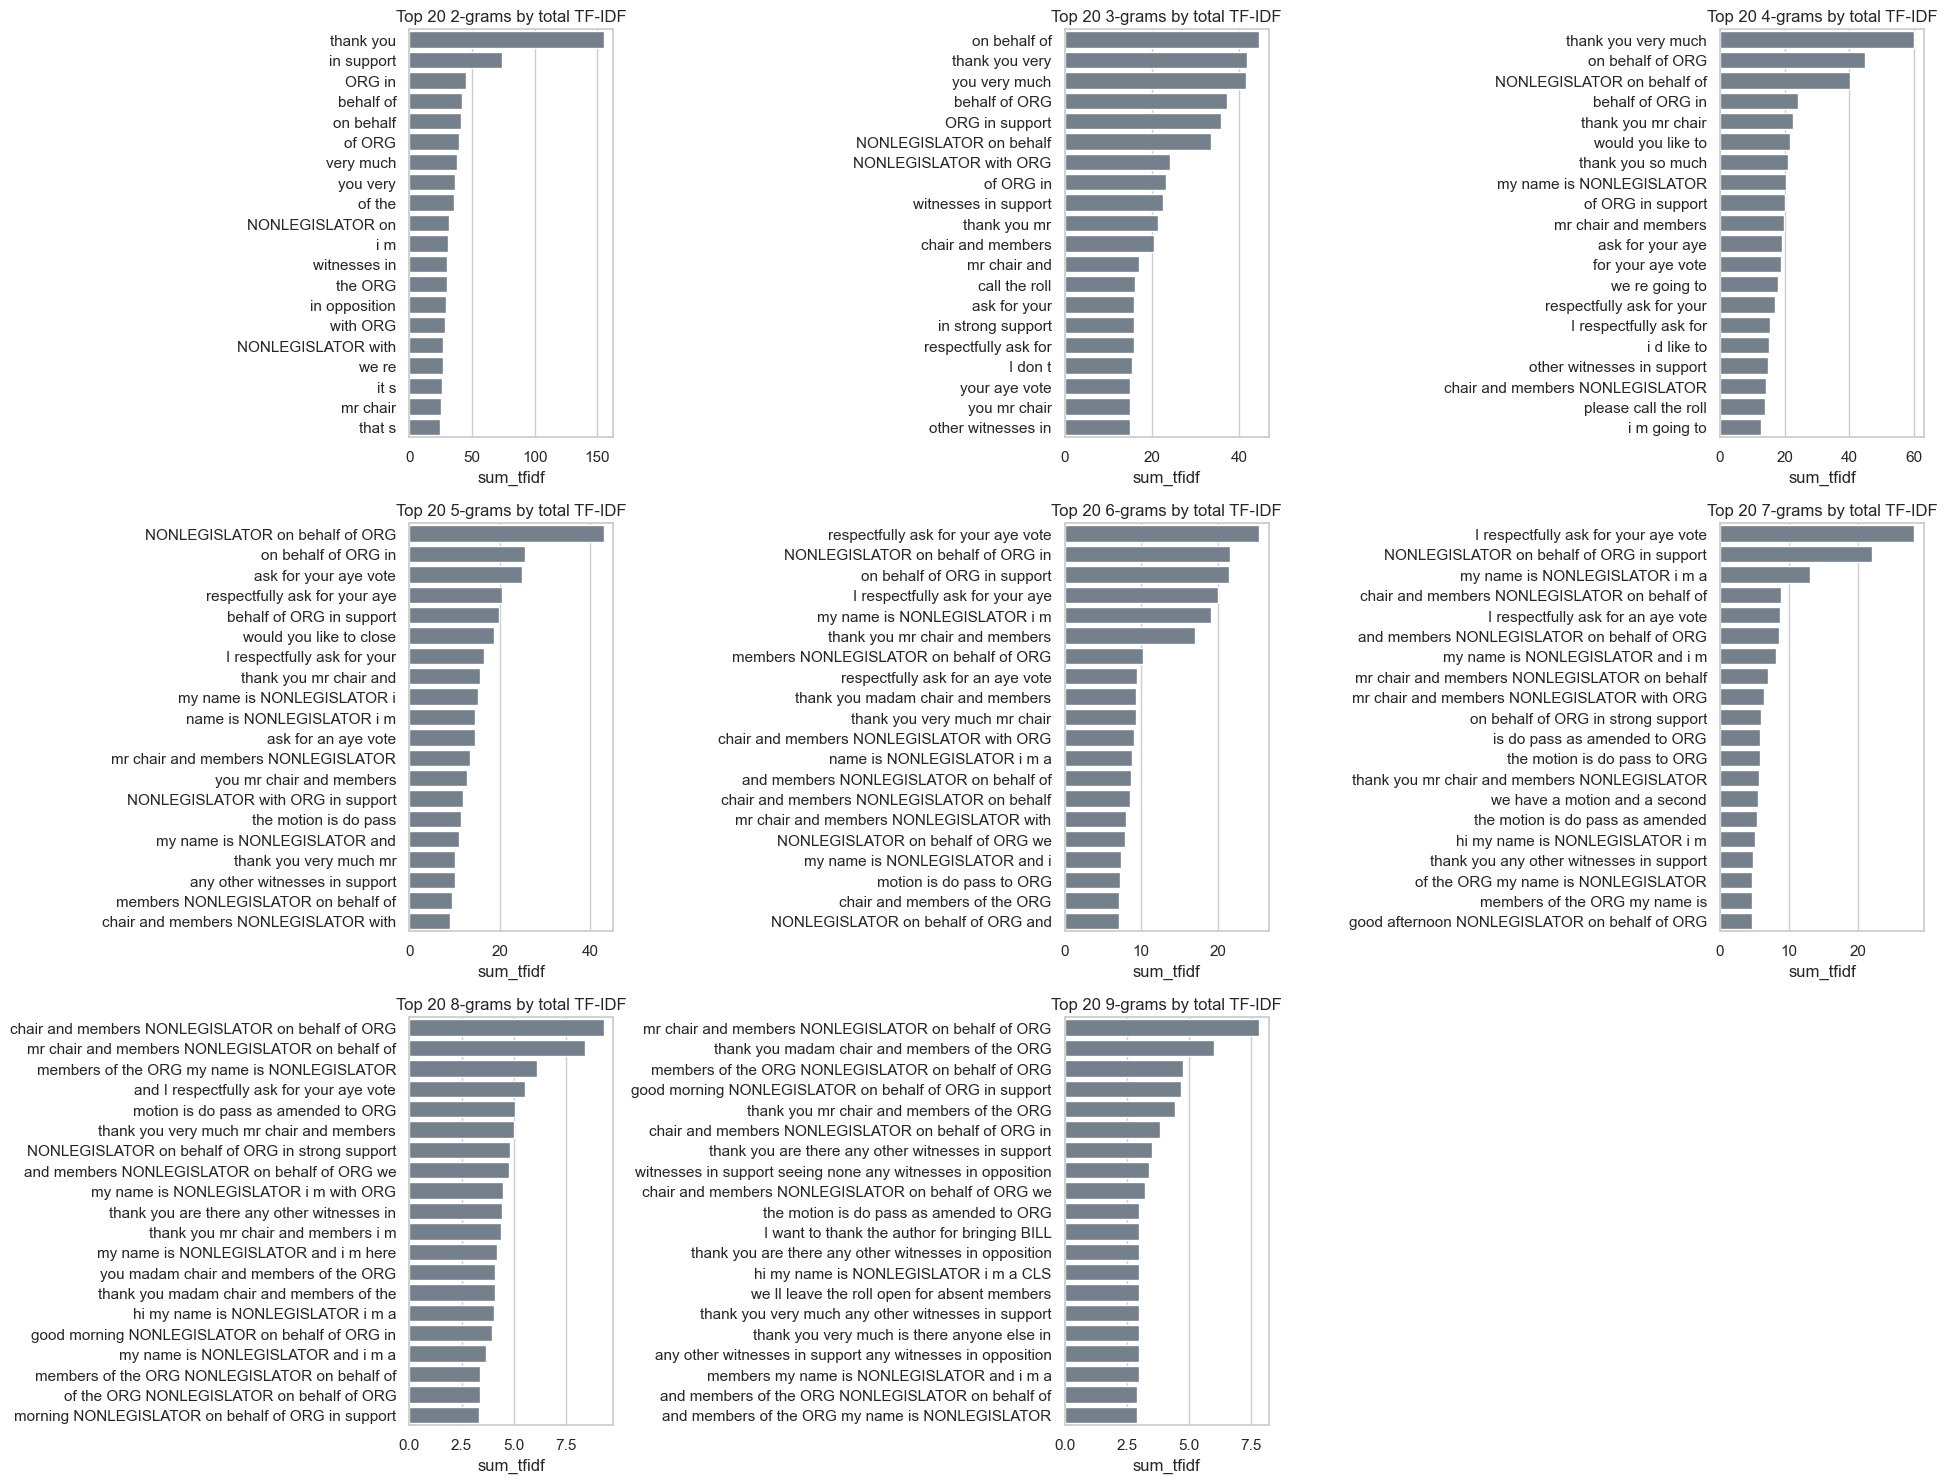

In [ ]:
# Top n-grams by summed TF-IDF weight for each n
def top_features(vec, X, k=20):
    s = np.asarray(X.sum(axis=0)).ravel()
    idx = np.argsort(-s)[:k]
    return pd.DataFrame({"ngram": vec.get_feature_names_out()[idx], "sum_tfidf": s[idx]})

# Calculate grid dimensions based on number of n-gram sizes
n_ngrams = len(ngram_range)
ncols = min(3, n_ngrams)
nrows = int(np.ceil(n_ngrams / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(6.5 * ncols, 5 * nrows))
if n_ngrams == 1:
    axes = np.array([axes])
axes = axes.ravel() if nrows > 1 or ncols > 1 else axes

for idx, n in enumerate(ngram_range):
    ax = axes[idx] if n_ngrams > 1 else axes[0]
    t = top_features(*tfidf[n], k=20)
    sns.barplot(data=t, y="ngram", x="sum_tfidf", ax=ax, color="slategray")
    ax.set_title(f"Top 20 {n}-grams by total TF-IDF"); ax.set_ylabel("")

# Hide unused subplots
for idx in range(n_ngrams, nrows * ncols):
    axes[idx].axis("off")

plt.tight_layout(); plt.show()

## 3. Keep only maximal n-grams

An n-gram that is contained within a longer n-gram in the vocabulary (`call the` ⊂ `call the roll`, `ask for` ⊂ `respectfully ask for`) carries no information the longer phrase doesn't already carry, and keeping both double-counts the same signal in the embedding and floods the correlation tables with nested variants of one phrase.

drop when a single longer phrase accounts for ≥ `CONTAIN_THRESHOLD` of the n-gram's occurrences

In [ ]:
CONTAIN_THRESHOLD = 0.6

def sub_ngrams(g):
    """All contiguous sub-n-grams of an n-gram string."""
    t = g.split()
    # Generate all sub-sequences from size MIN_NGRAM to len(t)-1
    return [" ".join(t[i:i + k]) for k in range(MIN_NGRAM, len(t)) for i in range(len(t) - k + 1)]

feat_index = pd.Index(feat_all)

from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(
    ngram_range=(MIN_NGRAM, MAX_NGRAM),
    token_pattern=TOKEN_PATTERN,
    lowercase=False,
    dtype=np.int32,
    min_df=5
)
cnt = pd.Series(
    np.asarray(cv.fit_transform(texts).sum(axis=0)).ravel(),
    index=cv.get_feature_names_out()
)
cnt_len = cnt.index.str.count(" ") + 1
best = pd.Series(0.0, index=cnt.index)
parent = pd.Series("", index=cnt.index)
for n in range(MIN_NGRAM, MAX_NGRAM):
    sup = cnt[cnt_len == n + 1]
    toks = sup.index.str.split(" ")
    for side in (toks.str[:-1].str.join(" "), toks.str[1:].str.join(" ")):
        m = pd.DataFrame({"p": side, "c": sup.values, "g": sup.index}).sort_values("c").drop_duplicates("p", keep="last").set_index("p")
        better = m["c"].reindex(best.index).fillna(0) > best
        best[better] = m["c"].reindex(best.index)[better]; parent[better] = m["g"].reindex(best.index)[better]
ratio = (best / cnt).reindex(feat_all).fillna(0.0)
keep_mask = (ratio < CONTAIN_THRESHOLD).values
absorbed_by = parent.reindex(feat_all[~keep_mask])

summary = (pd.DataFrame({"order": [f"{n}-gram" for n in ngram_len], "kept": keep_mask})
             .groupby("order")["kept"].agg(total="size", kept="sum"))
summary["dropped"] = summary["total"] - summary["kept"]
summary["dropped_pct"] = (100 * summary["dropped"] / summary["total"]).round(1)
print(f"keeping {keep_mask.sum():,} of {len(feat_all):,} features")
summary

keeping 17,598 of 19,807 features


,total,kept,dropped,dropped_pct
order,,,,
2-gram,9890,8971,919,9.3
3-gram,5858,5208,650,11.1
4-gram,2216,1894,322,14.5
5-gram,950,775,175,18.4
6-gram,455,366,89,19.6
7-gram,239,198,41,17.2
8-gram,128,115,13,10.2
9-gram,71,71,0,0.0


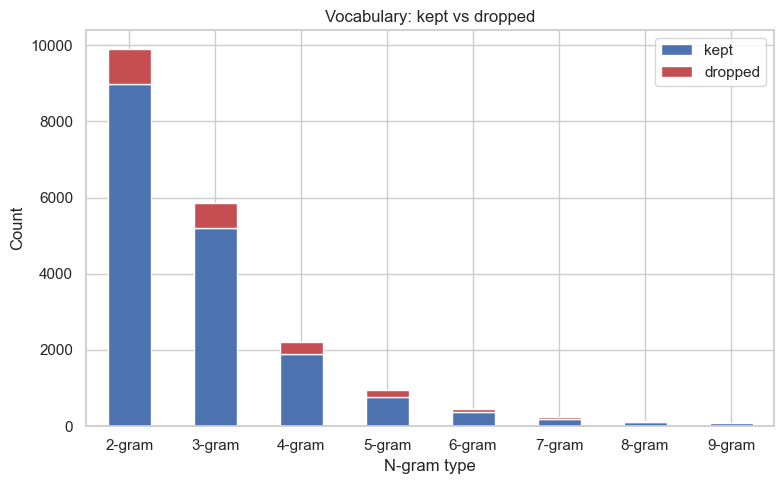

In [ ]:
# Vocabulary: kept vs dropped summary
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
summary[["kept", "dropped"]].plot.bar(stacked=True, ax=ax, rot=0, color=["#4c72b0", "#c44e52"])
ax.set_title("Vocabulary: kept vs dropped")
ax.set_xlabel("N-gram type")
ax.set_ylabel("Count")
# ax.set_scale("log")
plt.tight_layout(); plt.show()

In [ ]:
# Apply the filter to the embedding. Unfiltered copies are kept for comparison.
X_all_raw, feat_all_raw, ngram_len_raw = X_all, feat_all, ngram_len

X_all = normalize(X_all_raw[:, keep_mask])     # re-normalise rows after dropping columns
feat_all = feat_all_raw[keep_mask]
ngram_len = ngram_len_raw[keep_mask]
print("Filtered TF-IDF matrix:", X_all.shape,
      "| docs with no remaining feature:", int((X_all.getnnz(axis=1) == 0).sum()))

Filtered TF-IDF matrix: (2618, 17598) | docs with no remaining feature: 85


## 4. N-grams most correlated with each class (one-vs-rest)

For every n-gram feature *x* and every class *c*, we compute the **Pearson correlation** between the TF-IDF column *x* and the binary indicator `1[label == c]` (a point-biserial correlation). A high positive value means the n-gram is heavily weighted in class *c* relative to all other classes. This is computed fully sparse so it scales to the whole vocabulary.

Classes with fewer than `MIN_CLASS_SIZE` utterances are skipped (correlations there are pure noise).

In [ ]:
MIN_CLASS_SIZE = 10

def ngram_class_correlations(X, labels, feats):
    """Return DataFrame [features × classes] of Pearson r between each TF-IDF column and each one-vs-rest indicator."""
    X = sparse.csc_matrix(X, dtype=np.float64)
    n = X.shape[0]
    classes = [c for c, cnt in pd.Series(labels).value_counts().items() if cnt >= MIN_CLASS_SIZE]
    Y = np.column_stack([(labels == c).astype(np.float64) for c in classes])   # n × C

    mean_x = np.asarray(X.mean(axis=0)).ravel()
    mean_x2 = np.asarray(X.multiply(X).mean(axis=0)).ravel()
    sd_x = np.sqrt(np.maximum(mean_x2 - mean_x**2, 0))
    mean_y = Y.mean(axis=0)
    sd_y = np.sqrt(mean_y * (1 - mean_y))

    cov = (X.T @ Y) / n - np.outer(mean_x, mean_y)                            # V × C
    with np.errstate(divide="ignore", invalid="ignore"):
        r = cov / np.outer(sd_x, sd_y)
    r[~np.isfinite(r)] = 0.0
    return pd.DataFrame(r, index=feats, columns=classes)

def top_k_per_class(corr, k=10):
    frames = []
    for c in corr.columns:
        s = corr[c].nlargest(k)
        frames.append(pd.DataFrame({"class": c, "rank": range(1, k + 1), "ngram": s.index, "r": s.values}))
    return pd.concat(frames, ignore_index=True)

def plot_top_ngrams(top, title, ncols=3):
    classes = top["class"].unique()
    nrows = int(np.ceil(len(classes) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6.5 * ncols, 3.6 * nrows), squeeze=False)
    for ax, c in zip(axes.ravel(), classes):
        sub = top[top["class"] == c]
        sns.barplot(data=sub, y="ngram", x="r", ax=ax, color="steelblue")
        ax.set_title(f"{c} (n={int((df[title]==c).sum())})", fontsize=11); ax.set_ylabel(""); ax.set_xlabel("Pearson r (one-vs-rest)")
        ax.tick_params(axis="y", labelsize=8.5)
    for ax in axes.ravel()[len(classes):]:
        ax.axis("off")
    fig.suptitle(f"Top-10 n-grams by correlation with {title}", fontsize=14, y=1.01)
    plt.tight_layout(); plt.show()

### 4a. `speaker.position`

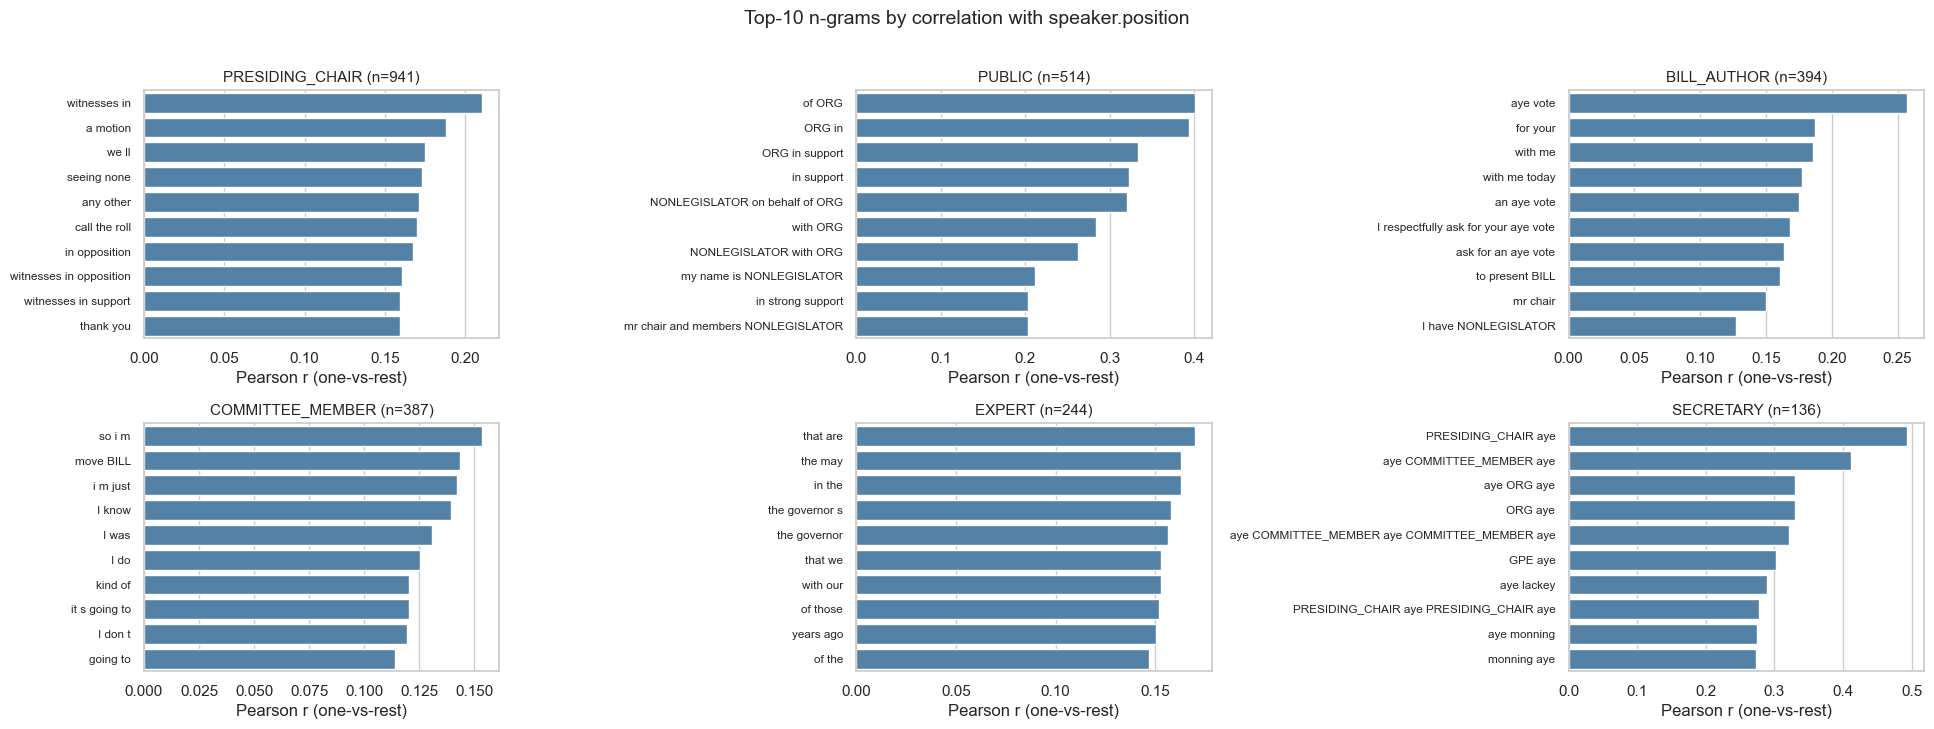

class,BILL_AUTHOR,COMMITTEE_MEMBER,EXPERT,PRESIDING_CHAIR,PUBLIC,SECRETARY
rank,,,,,,
1,aye vote,so i m,that are,witnesses in,of ORG,PRESIDING_CHAIR aye
2,for your,move BILL,the may,a motion,ORG in,aye COMMITTEE_MEMBER aye
3,with me,i m just,in the,we ll,ORG in support,aye ORG aye
4,with me today,I know,the governor s,seeing none,in support,ORG aye
5,an aye vote,I was,the governor,any other,NONLEGISLATOR on behalf of ORG,aye COMMITTEE_MEMBER aye COMMITTEE_MEMBER aye
6,I respectfully ask for your aye vote,I do,that we,call the roll,with ORG,GPE aye
7,ask for an aye vote,kind of,with our,in opposition,NONLEGISLATOR with ORG,aye lackey
8,to present BILL,it s going to,of those,witnesses in opposition,my name is NONLEGISLATOR,PRESIDING_CHAIR aye PRESIDING_CHAIR aye
9,mr chair,I don t,years ago,witnesses in support,in strong support,aye monning


In [ ]:
corr_speaker = ngram_class_correlations(X_all, df["speaker.position"].values, feat_all)
top_speaker = top_k_per_class(corr_speaker, k=10)
plot_top_ngrams(top_speaker, "speaker.position")
top_speaker.pivot(index="rank", columns="class", values="ngram")

### 4b. `section`

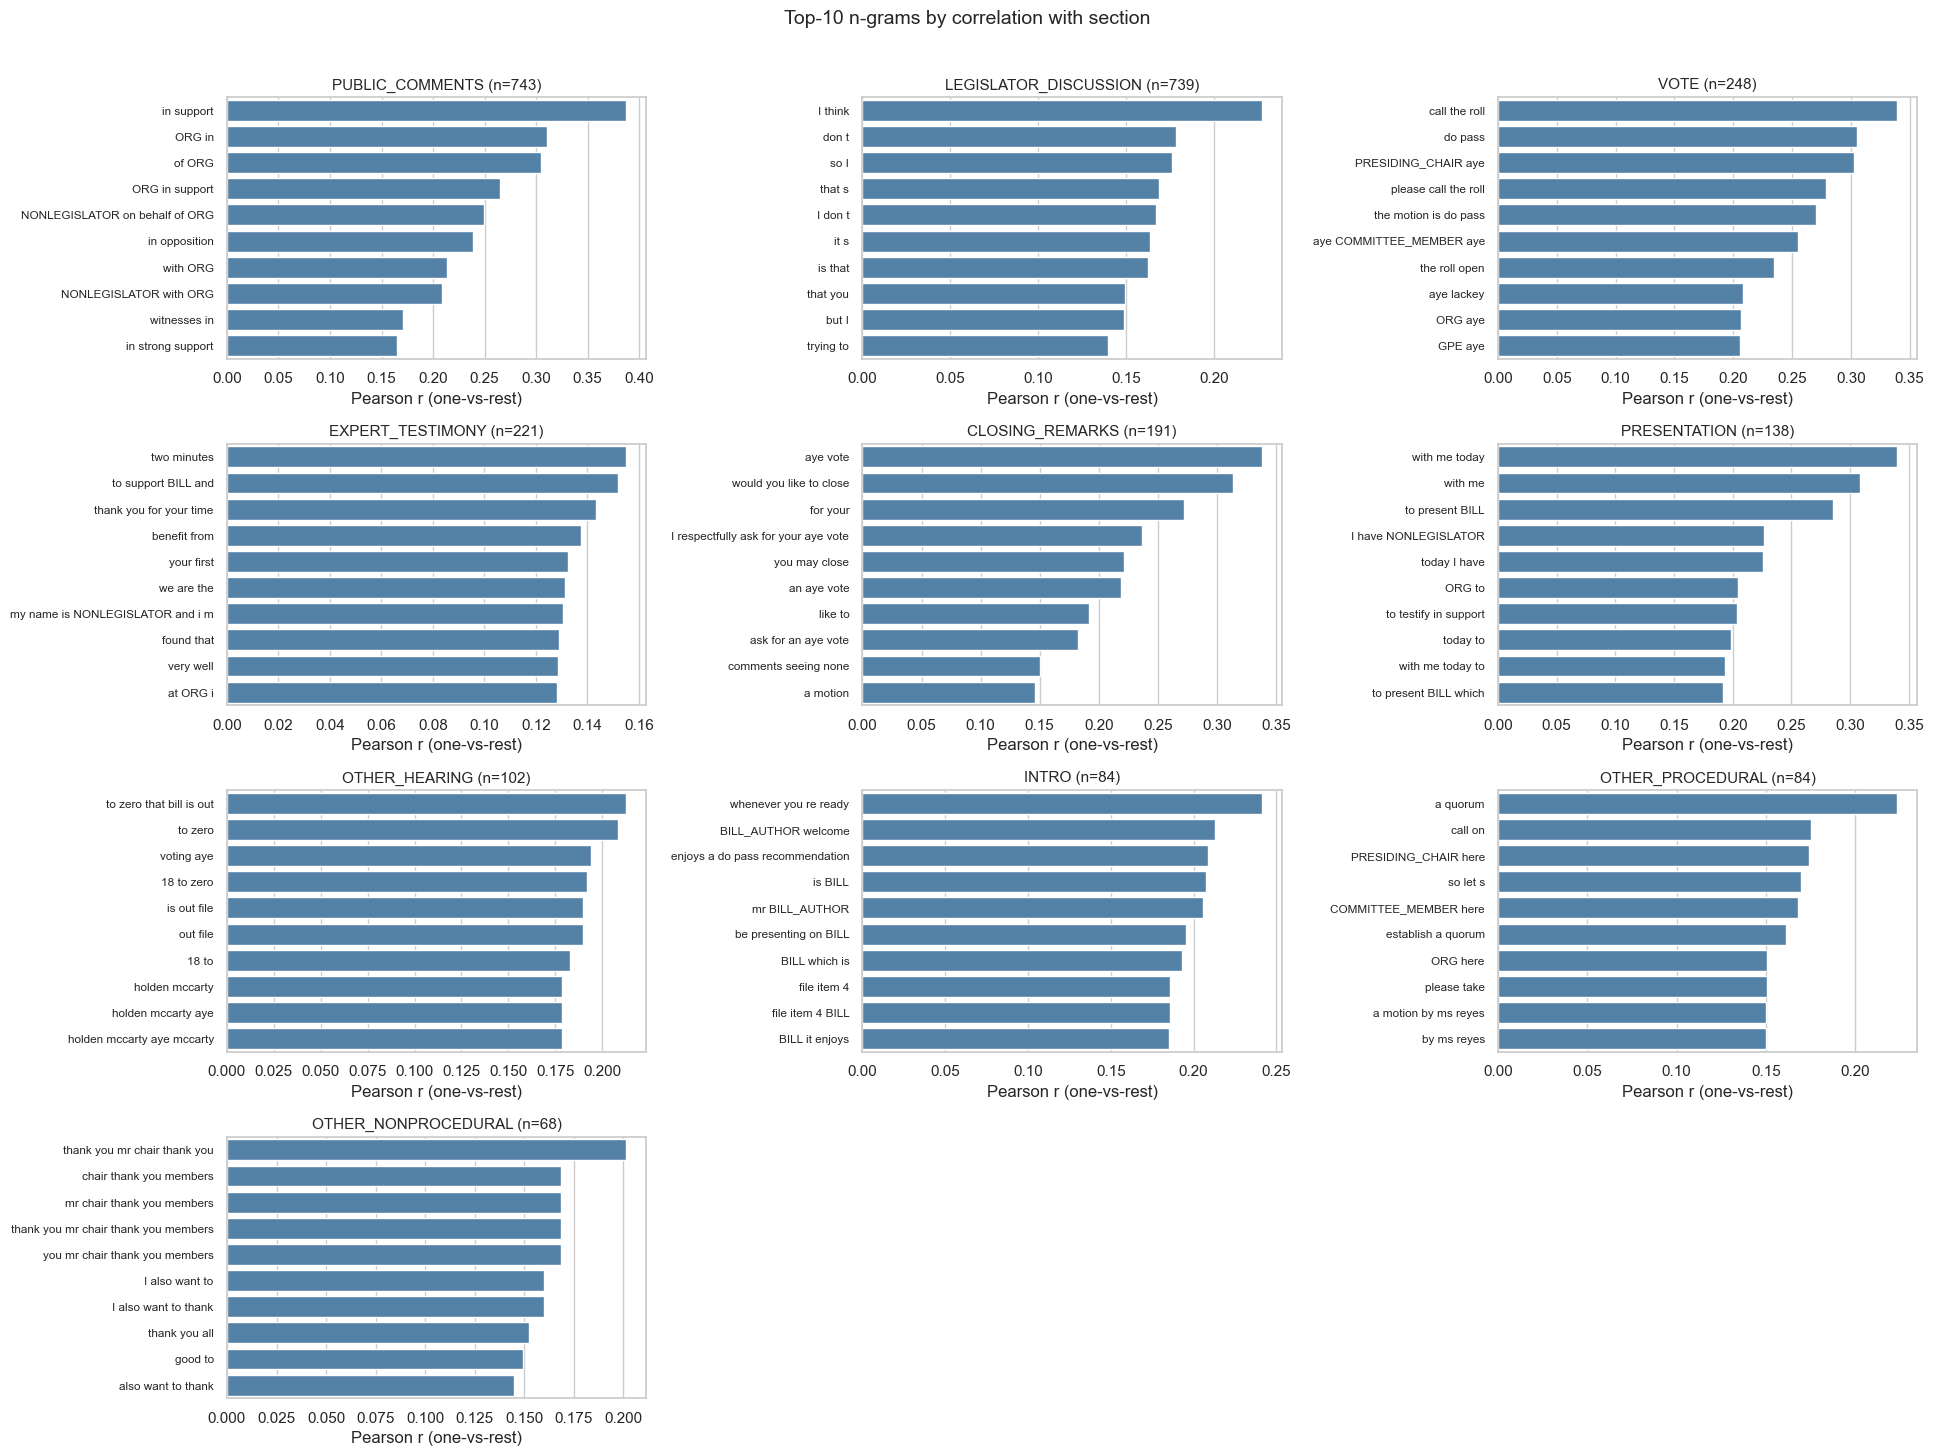

class,CLOSING_REMARKS,EXPERT_TESTIMONY,INTRO,LEGISLATOR_DISCUSSION,OTHER_HEARING,OTHER_NONPROCEDURAL,OTHER_PROCEDURAL,PRESENTATION,PUBLIC_COMMENTS,VOTE
rank,,,,,,,,,,
1,aye vote,two minutes,whenever you re ready,I think,to zero that bill is out,thank you mr chair thank you,a quorum,with me today,in support,call the roll
2,would you like to close,to support BILL and,BILL_AUTHOR welcome,don t,to zero,chair thank you members,call on,with me,ORG in,do pass
3,for your,thank you for your time,enjoys a do pass recommendation,so I,voting aye,mr chair thank you members,PRESIDING_CHAIR here,to present BILL,of ORG,PRESIDING_CHAIR aye
4,I respectfully ask for your aye vote,benefit from,is BILL,that s,18 to zero,thank you mr chair thank you members,so let s,I have NONLEGISLATOR,ORG in support,please call the roll
5,you may close,your first,mr BILL_AUTHOR,I don t,is out file,you mr chair thank you members,COMMITTEE_MEMBER here,today I have,NONLEGISLATOR on behalf of ORG,the motion is do pass
6,an aye vote,we are the,be presenting on BILL,it s,out file,I also want to,establish a quorum,ORG to,in opposition,aye COMMITTEE_MEMBER aye
7,like to,my name is NONLEGISLATOR and i m,BILL which is,is that,18 to,I also want to thank,ORG here,to testify in support,with ORG,the roll open
8,ask for an aye vote,found that,file item 4,that you,holden mccarty,thank you all,please take,today to,NONLEGISLATOR with ORG,aye lackey
9,comments seeing none,very well,file item 4 BILL,but I,holden mccarty aye,good to,a motion by ms reyes,with me today to,witnesses in,ORG aye


In [ ]:
corr_section = ngram_class_correlations(X_all, df["section"].values, feat_all)
top_section = top_k_per_class(corr_section, k=10)
plot_top_ngrams(top_section, "section", ncols=3)
top_section.pivot(index="rank", columns="class", values="ngram")

## 5. Clustering the n-gram TF-IDF embedding

We cluster utterances in the **maximal-n-gram TF-IDF space** built in §3. Design choices:

- **Rows with no surviving feature** (very short utterances such as `yes`, `aye`) are all-zero vectors and would form a degenerate cluster, so they are excluded from clustering and t-SNE and reported separately.
- **Dimensionality reduction first.** The TF-IDF matrix is very wide and very sparse; K-Means on it directly is slow and noisy. We project to `SVD_DIM` components with `TruncatedSVD` (i.e. Latent Semantic Analysis), then L2-normalise so Euclidean K-Means ≈ spherical (cosine) K-Means.
- **Model selection.** We sweep `K_RANGE` and look at inertia (elbow), silhouette (cosine), and Calinski–Harabasz; `N_CLUSTERS` defaults to the silhouette-best *k* but can be overridden.
- **Cluster profiles** are read off the cluster centroids *in the original TF-IDF space* (mean TF-IDF per cluster), so each cluster is labelled by its most characteristic n-grams.

Utterances with >=1 surviving feature: 2,533 / 2,618 (85 excluded from clustering / t-SNE)
LSA: 100 components explain 23.0% of TF-IDF variance


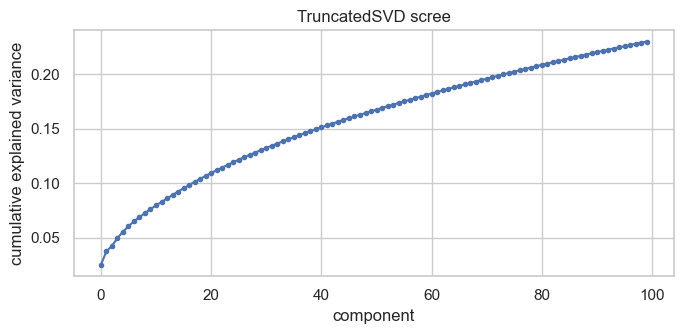

In [ ]:
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, adjusted_rand_score, normalized_mutual_info_score

# ===== CLUSTERING CONFIGURATION =====
SVD_DIM = 100                 # LSA dimensionality before clustering / t-SNE
K_RANGE = range(3, 16)        # candidate numbers of clusters
N_CLUSTERS = 4                # None -> pick k with the best silhouette in K_RANGE
# ====================================

has_feat = np.asarray(X_all.getnnz(axis=1) > 0)
print(f"Utterances with >=1 surviving feature: {has_feat.sum():,} / {len(df):,} "
      f"({(~has_feat).sum()} excluded from clustering / t-SNE)")

X_clu = X_all[has_feat]
df_clu = df.loc[has_feat].copy()

svd = TruncatedSVD(n_components=SVD_DIM, random_state=RANDOM_STATE)
Z = svd.fit_transform(X_clu)
Z = normalize(Z)                                        # unit rows -> cosine geometry
print(f"LSA: {SVD_DIM} components explain {svd.explained_variance_ratio_.sum():.1%} of TF-IDF variance")

plt.figure(figsize=(7, 3.5))
plt.plot(np.cumsum(svd.explained_variance_ratio_), marker=".")
plt.xlabel("component"); plt.ylabel("cumulative explained variance"); plt.title("TruncatedSVD scree")
plt.tight_layout(); plt.show()

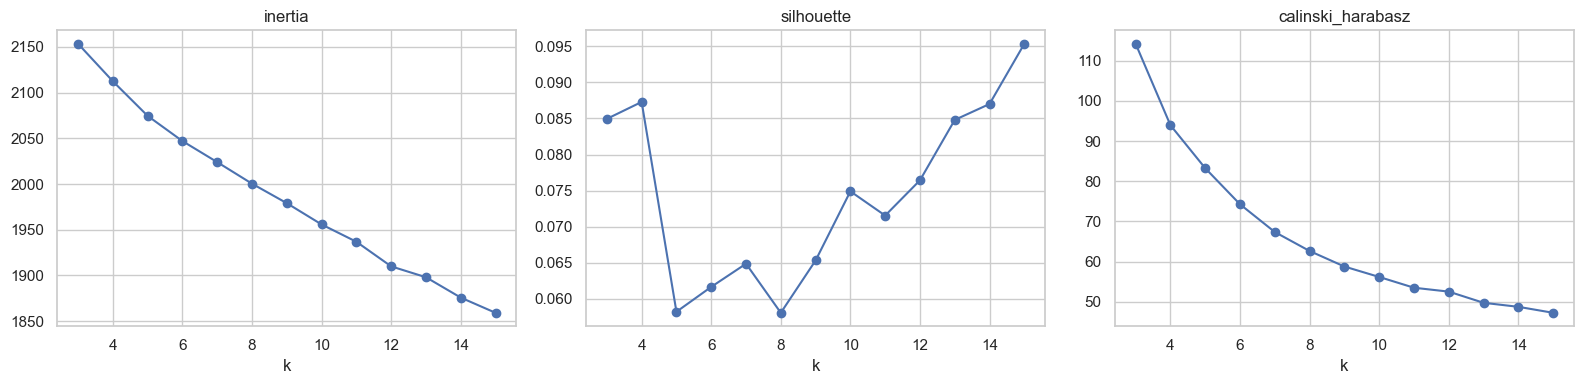

Using N_CLUSTERS = 4


,inertia,silhouette,calinski_harabasz
k,,,
3,2153.4612,0.0849,114.2053
4,2112.4585,0.0873,93.9464
5,2074.5935,0.0582,83.2525
6,2047.0399,0.0617,74.2747
7,2023.9799,0.0649,67.3726
8,2000.4087,0.0581,62.6557
9,1979.0924,0.0653,58.7904
10,1955.8209,0.0749,56.1946
11,1936.8815,0.0715,53.5155


In [ ]:
# --- model selection over k ---
sel = []
for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(Z)
    sel.append({
        "k": k,
        "inertia": km.inertia_,
        "silhouette": silhouette_score(Z, km.labels_, metric="cosine", random_state=RANDOM_STATE),
        "calinski_harabasz": calinski_harabasz_score(Z, km.labels_),
    })
sel = pd.DataFrame(sel).set_index("k")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["inertia", "silhouette", "calinski_harabasz"]):
    sel[col].plot(ax=ax, marker="o"); ax.set_title(col); ax.set_xlabel("k")
plt.tight_layout(); plt.show()

if N_CLUSTERS is None:
    N_CLUSTERS = int(sel["silhouette"].idxmax())
print(f"Using N_CLUSTERS = {N_CLUSTERS}")
sel.round(4)

Cluster sizes:
cluster
0     138
1     303
2    1287
3     805


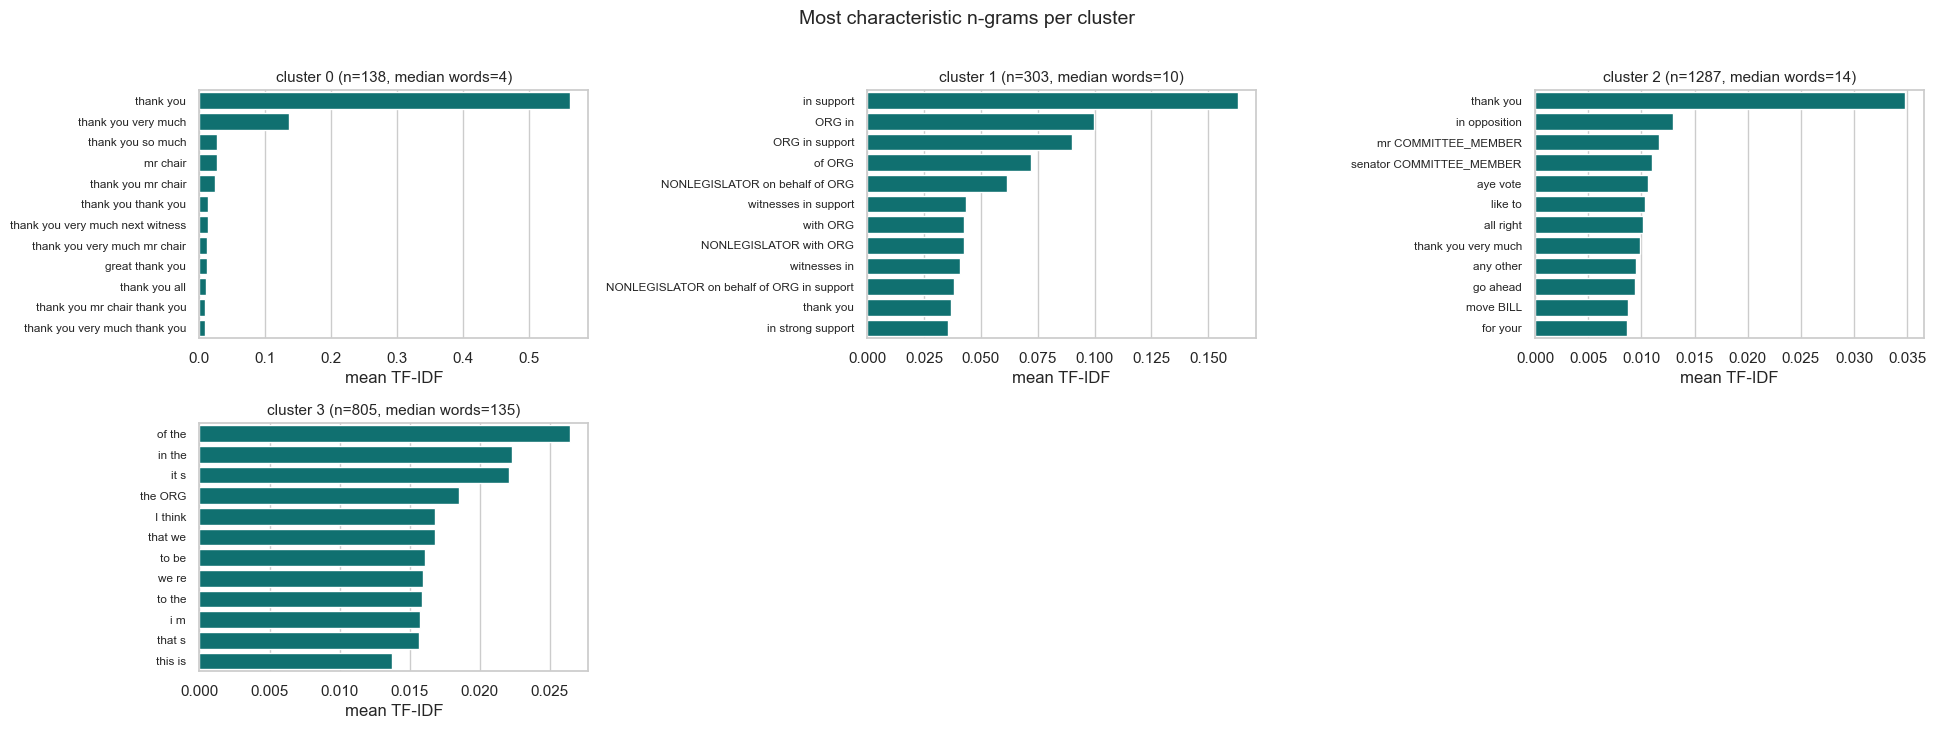

cluster,0,1,2,3
rank,,,,
1,thank you,in support,thank you,of the
2,thank you very much,ORG in,in opposition,in the
3,thank you so much,ORG in support,mr COMMITTEE_MEMBER,it s
4,mr chair,of ORG,senator COMMITTEE_MEMBER,the ORG
5,thank you mr chair,NONLEGISLATOR on behalf of ORG,aye vote,I think
6,thank you thank you,witnesses in support,like to,that we
7,thank you very much next witness,with ORG,all right,to be
8,thank you very much mr chair,NONLEGISLATOR with ORG,thank you very much,we re


In [ ]:
# --- final model ---
kmeans = KMeans(n_clusters=N_CLUSTERS, n_init=20, random_state=RANDOM_STATE).fit(Z)
df_clu["cluster"] = kmeans.labels_
df["cluster"] = -1                               # -1 = no surviving feature / not clustered
df.loc[has_feat, "cluster"] = kmeans.labels_

sizes = df_clu["cluster"].value_counts().sort_index()
print("Cluster sizes:"); print(sizes.to_string())

# top n-grams per cluster from mean TF-IDF (centroid in the original feature space)
def cluster_top_ngrams(X, labels, feats, k=12):
    rows = []
    for c in np.unique(labels):
        centroid = np.asarray(X[labels == c].mean(axis=0)).ravel()
        idx = np.argsort(-centroid)[:k]
        rows.append(pd.DataFrame({"cluster": c, "rank": range(1, k + 1), "ngram": feats[idx], "mean_tfidf": centroid[idx]}))
    return pd.concat(rows, ignore_index=True)

top_clusters = cluster_top_ngrams(X_clu, kmeans.labels_, feat_all, k=12)

ncols = 3
nrows = int(np.ceil(N_CLUSTERS / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(6.5 * ncols, 3.6 * nrows), squeeze=False)
for ax, c in zip(axes.ravel(), range(N_CLUSTERS)):
    sub = top_clusters[top_clusters["cluster"] == c]
    sns.barplot(data=sub, y="ngram", x="mean_tfidf", ax=ax, color="teal")
    ax.set_title(f"cluster {c} (n={sizes[c]}, median words={int(df_clu.loc[df_clu.cluster==c, 'n_words'].median())})", fontsize=11)
    ax.set_ylabel(""); ax.set_xlabel("mean TF-IDF"); ax.tick_params(axis="y", labelsize=8.5)
for ax in axes.ravel()[N_CLUSTERS:]:
    ax.axis("off")
fig.suptitle("Most characteristic n-grams per cluster", fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

top_clusters.pivot(index="rank", columns="cluster", values="ngram").head(8)

### 5a. How do clusters relate to the labels?

Row-normalised cross-tabs show what each cluster is *made of*; ARI / NMI quantify overall agreement between the unsupervised partition and each label column (0 ≈ independent, 1 = identical partition).

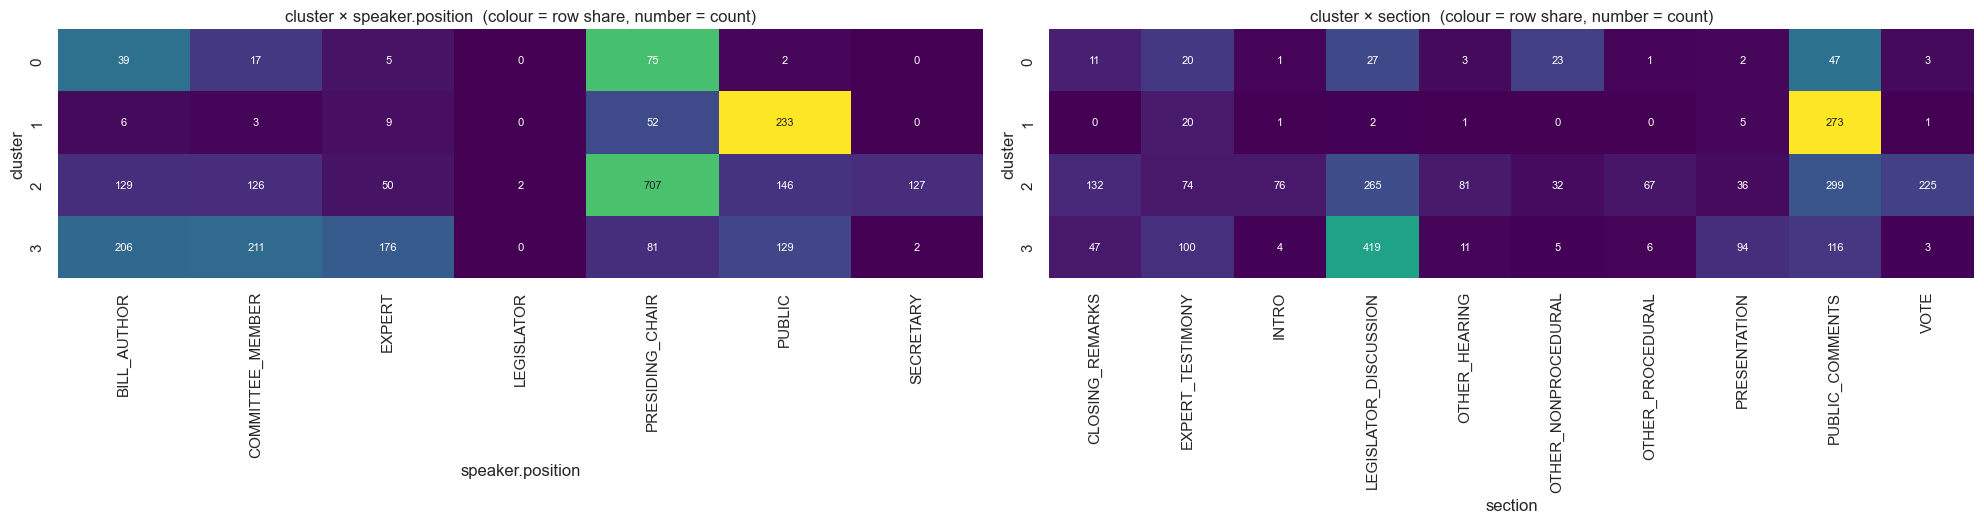

,ARI,NMI
speaker.position,0.169,0.198
section,0.057,0.174


In [ ]:
def cluster_label_heatmap(label, ax):
    ct = pd.crosstab(df_clu["cluster"], df_clu[label])
    ct_norm = ct.div(ct.sum(axis=1), axis=0)
    sns.heatmap(ct_norm, annot=ct, fmt="d", cmap="viridis", cbar=False, ax=ax, annot_kws={"size": 8})
    ax.set_title(f"cluster × {label}  (colour = row share, number = count)")
    return ct

fig, axes = plt.subplots(1, 2, figsize=(20, 0.6 * N_CLUSTERS + 3))
ct_speaker = cluster_label_heatmap("speaker.position", axes[0])
ct_section = cluster_label_heatmap("section", axes[1])
plt.tight_layout(); plt.show()

agree = pd.DataFrame({
    label: {"ARI": adjusted_rand_score(df_clu[label], df_clu["cluster"]),
            "NMI": normalized_mutual_info_score(df_clu[label], df_clu["cluster"])}
    for label in ["speaker.position", "section"]
}).T
agree.round(3)

In [ ]:
# purity: for each cluster, share of its dominant class
purity = pd.DataFrame({
    "size": sizes,
    "top_speaker": ct_speaker.idxmax(axis=1),
    "speaker_purity": (ct_speaker.max(axis=1) / ct_speaker.sum(axis=1)).round(2),
    "top_section": ct_section.idxmax(axis=1),
    "section_purity": (ct_section.max(axis=1) / ct_section.sum(axis=1)).round(2),
})
purity

,size,top_speaker,speaker_purity,top_section,section_purity
cluster,,,,,
0,138,PRESIDING_CHAIR,0.54,PUBLIC_COMMENTS,0.34
1,303,PUBLIC,0.77,PUBLIC_COMMENTS,0.90
2,1287,PRESIDING_CHAIR,0.55,PUBLIC_COMMENTS,0.23
3,805,COMMITTEE_MEMBER,0.26,LEGISLATOR_DISCUSSION,0.52


In [ ]:
# A few example utterances per cluster (closest to the centroid), truncated for display
dists = kmeans.transform(Z)                       # distance of each row to every centroid
examples = []
for c in range(N_CLUSTERS):
    idx = np.where(kmeans.labels_ == c)[0]
    closest = idx[np.argsort(dists[idx, c])[:3]]
    for i in closest:
        r = df_clu.iloc[i]
        examples.append({"cluster": c, "speaker.position": r["speaker.position"], "section": r["section"],
                         "text": r["text"][:140] + ("…" if len(r["text"]) > 140 else "")})
pd.set_option("display.max_colwidth", 150)
pd.DataFrame(examples)

,cluster,speaker.position,section,text
0,0,PRESIDING_CHAIR,PUBLIC_COMMENTS,thank you
1,0,PRESIDING_CHAIR,PUBLIC_COMMENTS,thank you
2,0,PRESIDING_CHAIR,PUBLIC_COMMENTS,thank you
3,1,PUBLIC,PUBLIC_COMMENTS,eddie moreno on behalf of ORG in support
4,1,PUBLIC,PUBLIC_COMMENTS,mike robson here on behalf of ORG in support
5,1,PUBLIC,PUBLIC_COMMENTS,bill mcgavin with ORG in support
6,2,PRESIDING_CHAIR,VOTE,okay so that bill currently has five votes so we'll put BILL on call for the other members as well so thank you okay so what we're going to …
7,2,PRESIDING_CHAIR,INTRO,good afternoon we're going to go ahead and begin ORG hearing today we're a little short of a quorum as you might notice we will have some ti…
8,2,PRESIDING_CHAIR,VOTE,BILL has adequate votes but we will hold it open because we will now go through the roll for the bills that are outstanding and sergeant if …
9,3,BILL_AUTHOR,PRESENTATION,members many of you know that I came to this position having served for two terms on school board in my hometown of GPE and I was elected in…


## 6. t-SNE embedding

t-SNE is run on the **LSA-reduced, L2-normalised** representation `Z` (the same input as K-Means) with a cosine metric. Running t-SNE on the raw sparse TF-IDF matrix is both slow and dominated by the near-orthogonality of high-dimensional sparse vectors; reducing first is the standard recipe.

Reading the plots:
- Colour by `speaker.position` and `section` shows whether the n-gram signal separates the *known* structure.
- Colour by K-Means cluster shows whether the clusters are compact regions or cut across visible structure.
- Point size ∝ log utterance length — very short procedural utterances often form tight islands.

`TSNE_PERPLEXITY` controls the local/global trade-off (5–50 is the usual range); try a couple of values if the layout looks fragmented.

In [ ]:
from sklearn.manifold import TSNE

# ===== T-SNE CONFIGURATION =====
TSNE_PERPLEXITY = 1000
TSNE_MAX_ITER = 4000
# ===============================

tsne = TSNE(n_components=2, perplexity=TSNE_PERPLEXITY, metric="cosine", init="pca",
            max_iter=TSNE_MAX_ITER, random_state=RANDOM_STATE)
emb = tsne.fit_transform(Z)
df_clu["tsne_x"], df_clu["tsne_y"] = emb[:, 0], emb[:, 1]
print("t-SNE done; KL divergence =", round(float(tsne.kl_divergence_), 3))

t-SNE done; KL divergence = 0.53


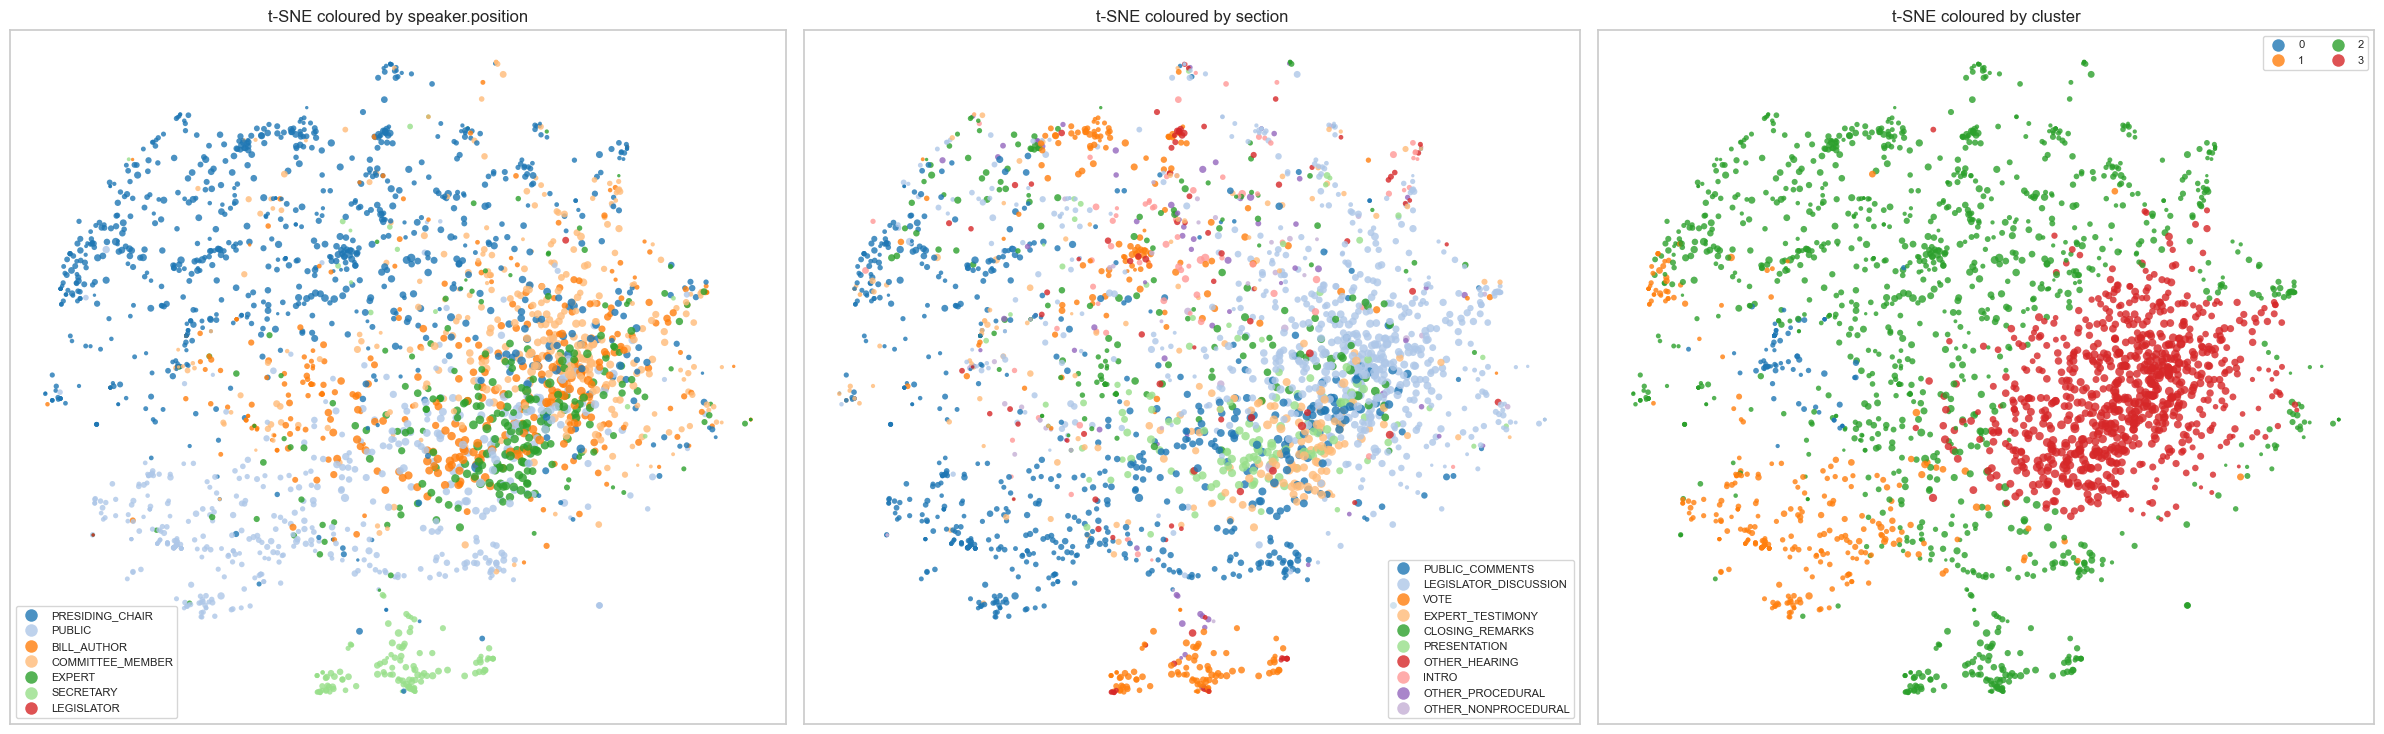

In [ ]:
def tsne_plot(hue, ax, palette="tab20", legend_cols=1):

    order = sorted(df_clu[hue].unique())
    if df_clu[hue].dtype == object:
        order = df_clu[hue].value_counts().index\
    
    sns.scatterplot(
        data=df_clu,
        x="tsne_x",
        y="tsne_y",
        hue=hue,
        hue_order=order,
        size=np.log1p(df_clu["n_words"]),
        sizes=(6, 60),
        alpha=0.8,
        palette=palette,
        ax=ax,
        linewidth=0
    )

    ax.set_title(f"t-SNE coloured by {hue}")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticks([])
    ax.set_yticks([])
    
    h, l = ax.get_legend_handles_labels()
    n_hue = len(order)
    ax.legend(
        h[1:n_hue + 1],
        l[1:n_hue + 1],
        loc="best",
        fontsize=8,
        ncol=legend_cols,
        markerscale=1.5,
        frameon=True
    )

fig, axes = plt.subplots(1, 3, figsize=(24, 7.5))
tsne_plot("speaker.position", axes[0])
tsne_plot("section", axes[1])
tsne_plot("cluster", axes[2], palette="tab10" if N_CLUSTERS <= 10 else "tab20", legend_cols=2)
plt.tight_layout(); plt.show()

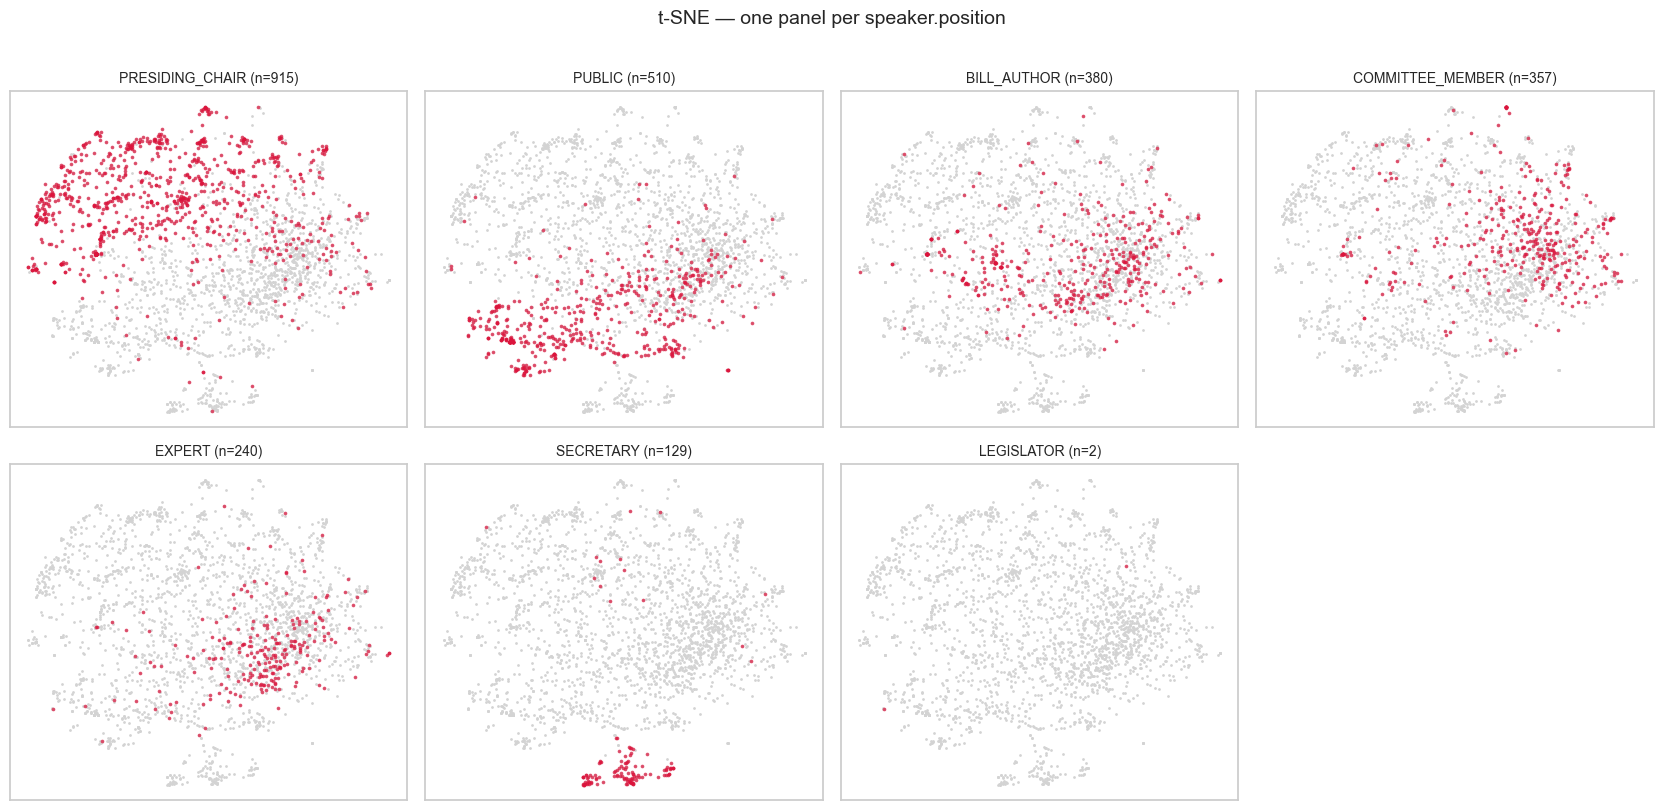

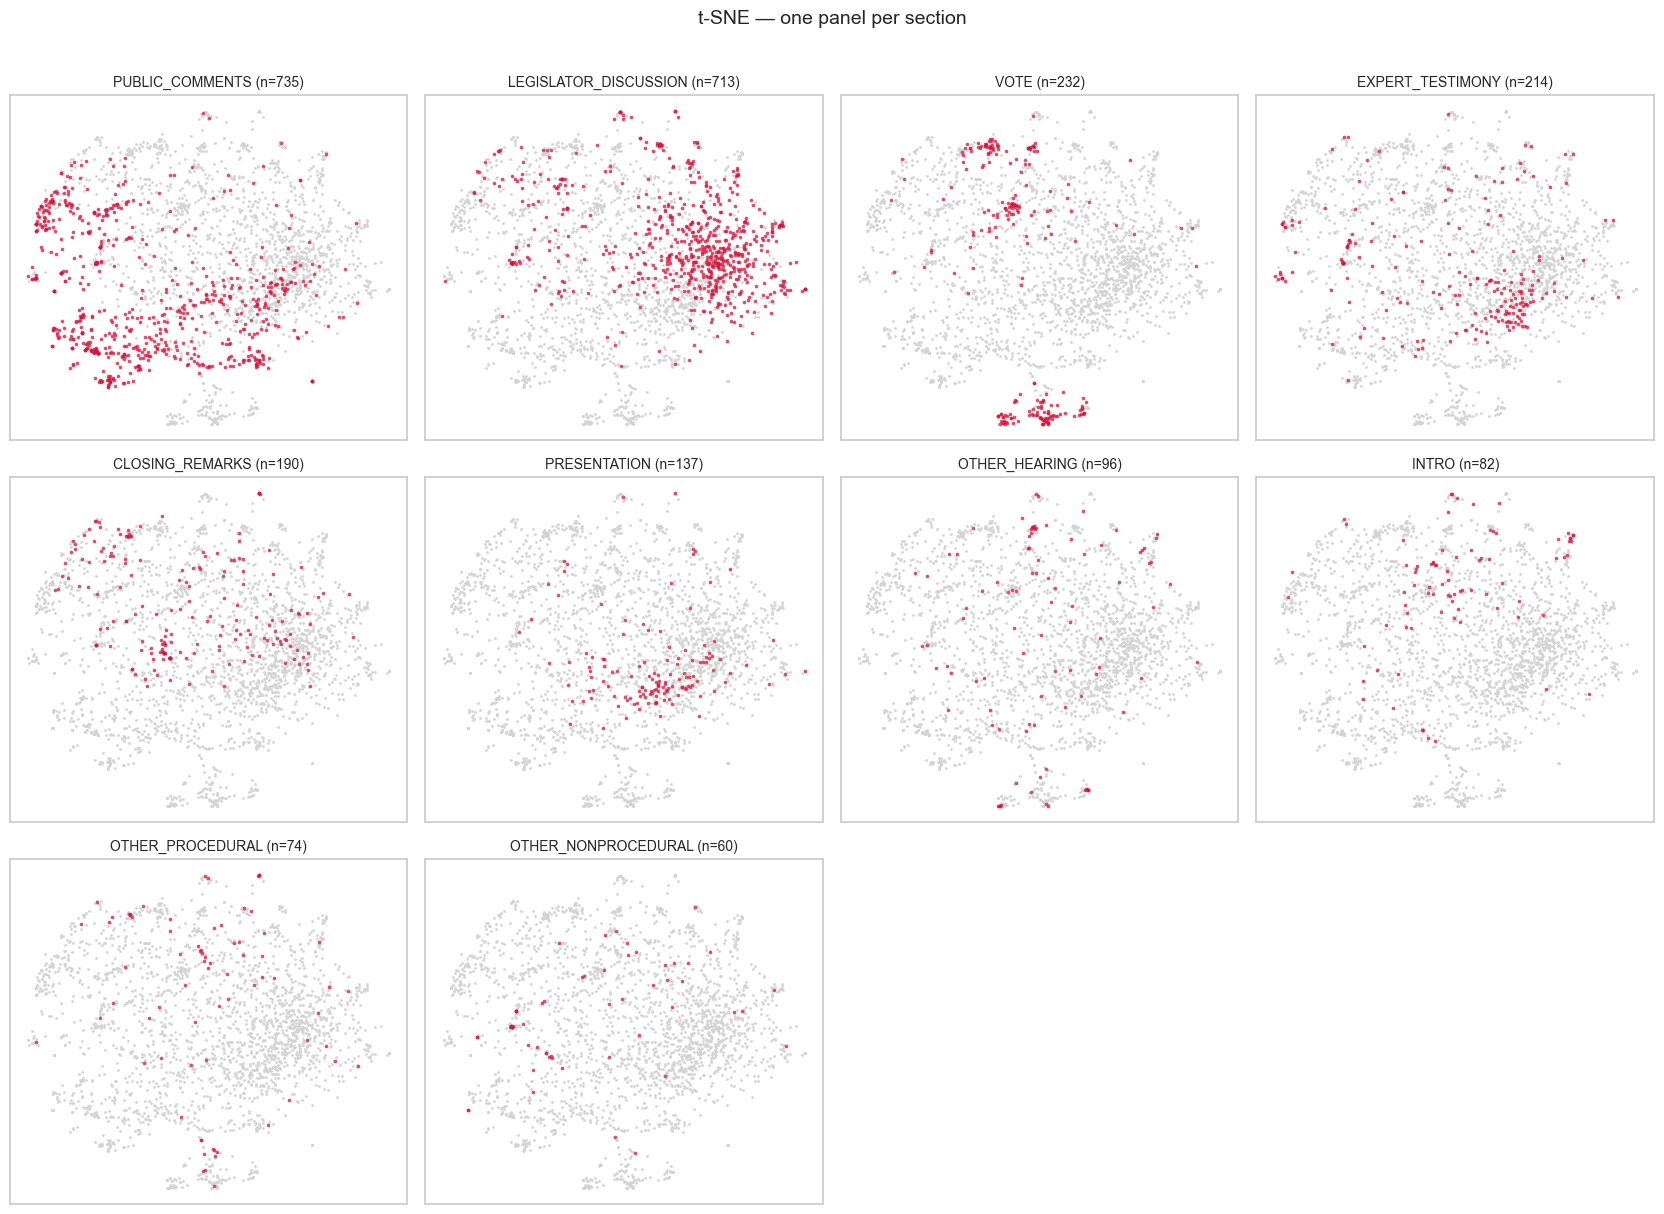

In [ ]:
# Small-multiples: one panel per class, so overlapping classes can be told apart
def tsne_facets(hue, ncols=4, top_n=None):

    classes = df_clu[hue].value_counts().index
    if top_n:
        classes = classes[:top_n]
    
    nrows = int(np.ceil(len(classes) / ncols))
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(4.2 * ncols, 4 * nrows),
        squeeze=False
    )

    for ax, c in zip(axes.ravel(), classes):
        ax.scatter(
            df_clu["tsne_x"],
            df_clu["tsne_y"],
            s=4,
            color="lightgray",
            linewidths=0
        )

        m = df_clu[hue] == c
        ax.scatter(
            df_clu.loc[m, "tsne_x"],
            df_clu.loc[m, "tsne_y"],
            s=7,
            color="crimson",
            alpha=0.7,
            linewidths=0
        )

        ax.set_title(f"{c} (n={m.sum()})", fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])

    for ax in axes.ravel()[len(classes):]:
        ax.axis("off")
    
    fig.suptitle(f"t-SNE — one panel per {hue}", fontsize=14, y=1.01)
    plt.tight_layout(); plt.show()

tsne_facets("speaker.position")
tsne_facets("section")

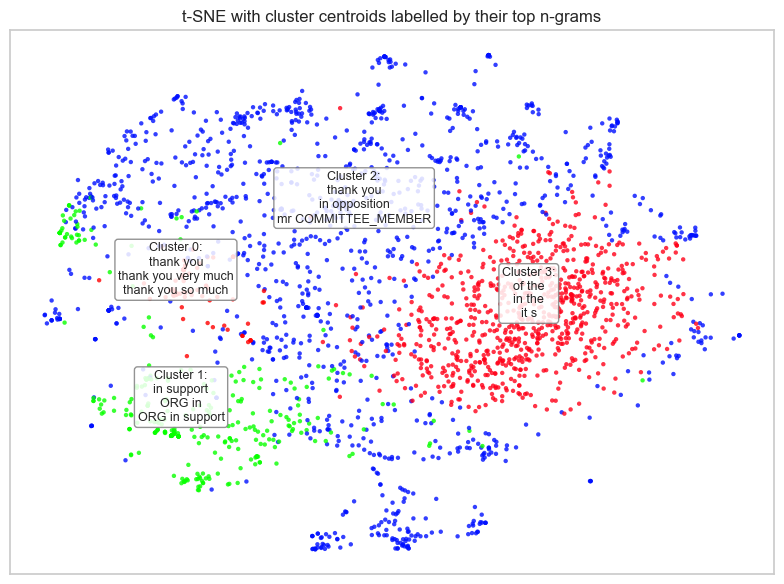

In [ ]:
# Annotate each cluster's centroid in t-SNE space with its top-3 n-grams
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(
    df_clu["tsne_x"],
    df_clu["tsne_y"],
    c=df_clu["cluster"],
    cmap="hsv",
    s=10,
    alpha=0.8,
    linewidths=0
)

for c in range(N_CLUSTERS):
    m = df_clu["cluster"] == c
    cx, cy = df_clu.loc[m, "tsne_x"].median(), df_clu.loc[m, "tsne_y"].median()
    label = "\n".join(top_clusters.loc[top_clusters.cluster == c, "ngram"].head(3))
    ax.annotate(
        f"Cluster {c}:\n{label}",
        (cx, cy),
        fontsize=9,
        ha="center",
        bbox=dict(
            boxstyle="round,pad=0.25",
            fc="white",
            ec="gray",
            alpha=0.85
        )
    )

ax.set_title("t-SNE with cluster centroids labelled by their top n-grams"); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

### 6a. Local neighbourhood purity in the t-SNE map

t-SNE preserves local structure, so a quick sanity check is: for each point, what fraction of its `KNN` nearest neighbours *in the 2-D map* share its label? A value well above the class-frequency baseline means the n-gram embedding carries real signal for that label; comparing against the same statistic in the 100-D LSA space shows how much t-SNE distorted things.

In [ ]:
from sklearn.neighbors import NearestNeighbors

KNN = 15

def knn_purity(coords, labels, k=KNN, metric="euclidean"):
    nn = NearestNeighbors(n_neighbors=k + 1, metric=metric).fit(coords)
    _, ind = nn.kneighbors(coords)
    lab = np.asarray(labels)
    same = (lab[ind[:, 1:]] == lab[:, None]).mean(axis=1)
    return pd.Series(same, index=labels.index)

rows = []
for label in ["speaker.position", "section", "cluster"]:
    p2d = knn_purity(emb, df_clu[label])
    pZ = knn_purity(Z, df_clu[label], metric="cosine")
    freq = df_clu[label].value_counts(normalize=True)
    baseline = float((freq ** 2).sum())        # expected purity if neighbours were random
    rows.append({"label": label, "kNN purity (t-SNE 2-D)": p2d.mean(), "kNN purity (LSA 100-D)": pZ.mean(),
                 "random baseline": baseline})
pd.DataFrame(rows).set_index("label").round(3)

,kNN purity (t-SNE 2-D),kNN purity (LSA 100-D),random baseline
label,,,
speaker.position,0.558,0.577,0.225
section,0.473,0.494,0.191
cluster,0.881,0.815,0.376
